# Timoshenko (Shear-Deformable) Beam Elements

By default `PyCBA` uses **Euler&ndash;Bernoulli** beam theory: plane sections stay
normal to the neutral axis, so the deflection comes from bending alone. This is
an excellent idealisation for *slender* members, but for **deep or short**
members &mdash; transfer beams, deep voided slabs, short spans &mdash; the
transverse **shear deformation** is no longer negligible.

A **Timoshenko** element adds that shear deformation. The cross section is
allowed to rotate independently of the beam axis, and the difference between the
axis slope and the section rotation is the shear strain $\gamma = V/GA_v$, where
$GA_v$ is the transverse **shear rigidity** ($A_v = kA$ is the shear area and $k$
the section shear coefficient).

In `PyCBA` you opt in *per member* simply by supplying a finite `GAv`:

* `GAv=None` (the default) &rarr; the exact Euler&ndash;Bernoulli element,
  unchanged.
* a finite `GAv` (a scalar, or a `SectionEI` for a variable $GA_v(x)$) &rarr; a
  shear-deformable Timoshenko element.

Everything else &mdash; two DOF per node, the `supports=` API, reactions,
plotting, influence lines &mdash; is inherited unchanged. See the
[Theoretical Basis](../theory.md) page for the formulation.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pycba as cba

## Example 1 &mdash; A simply-supported deep beam

Consider a stocky rectangular concrete beam: $E = 30\,\mathrm{GPa}$,
$b = 0.3\,\mathrm{m}$, $d = 1.0\,\mathrm{m}$, on a span $L = 5\,\mathrm{m}$
(span/depth $= 5$). For a rectangle the shear coefficient is $k = 5/6$, so the
shear area is $A_v = \tfrac{5}{6}A$ and the shear rigidity is $GA_v = G A_v$ with
$G = E / 2(1+\nu)$.

We work in consistent units of kN and m throughout.

In [2]:
E = 30.0e6          # kN/m^2  (30 GPa)
nu = 0.2
G = E / (2 * (1 + nu))

b, d = 0.3, 1.0     # m  (a deep section)
L = 5.0             # m  span (span/depth = 5)

I = b * d**3 / 12   # m^4
A = b * d           # m^2
k = 5.0 / 6.0       # rectangular shear coefficient
Av = k * A          # shear area

EI = E * I          # flexural rigidity
GAv = G * Av        # shear rigidity

Phi = 12 * EI / (GAv * L**2)
print(f"EI  = {EI:.4g} kN.m^2")
print(f"GAv = {GAv:.4g} kN")
print(f"shear parameter  Phi = 12 EI / (GAv L^2) = {Phi:.4f}")

EI  = 7.5e+05 kN.m^2
GAv = 3.125e+06 kN
shear parameter  Phi = 12 EI / (GAv L^2) = 0.1152


A central point load $P$ on a simply-supported span has the closed-form
midspan deflection

$$\delta_\text{mid} = \underbrace{\frac{PL^3}{48EI}}_{\text{bending}}
                    + \underbrace{\frac{PL}{4GA_v}}_{\text{shear}}.$$

We build the beam twice &mdash; once Euler&ndash;Bernoulli, once Timoshenko
(`GAv=...`) &mdash; and compare against this analytic result.

In [3]:
P = 100.0  # kN

def ss_midspan(GAv=None):
    # pinned-pinned single span: [v, theta] per node, vertical held, rotation free
    ba = cba.BeamAnalysis([L], EI, [-1, 0, -1, 0], GAv=GAv)
    ba.add_pl(1, P, L / 2)
    ba.analyze(npts=500)
    return ba.beam_results.results.D.min()

d_eb = ss_midspan(None)
d_ti = ss_midspan(GAv)

analytic_eb = -(P * L**3 / (48 * EI))
analytic_ti = -(P * L**3 / (48 * EI) + P * L / (4 * GAv))

print(f"Euler-Bernoulli midspan: {d_eb*1e3:8.4f} mm   (analytic {analytic_eb*1e3:8.4f} mm)")
print(f"Timoshenko    midspan: {d_ti*1e3:8.4f} mm   (analytic {analytic_ti*1e3:8.4f} mm)")
print(f"shear adds {100*(d_ti-d_eb)/d_eb:5.1f}% to the deflection (~ Phi = {100*Phi:.1f}%)")

Euler-Bernoulli midspan:  -0.3472 mm   (analytic  -0.3472 mm)
Timoshenko    midspan:  -0.3872 mm   (analytic  -0.3872 mm)
shear adds  11.5% to the deflection (~ Phi = 11.5%)


The shear deflection adds about $\Phi \approx 11\%$ for this deep beam, and
the Timoshenko result matches the textbook closed form. For a slender beam
($GA_v$ large, $\Phi \to 0$) the two coincide.

## Example 2 &mdash; When does shear matter? Span/depth sweep

The shear share of the deflection is set by $\Phi = 12EI/(GA_vL^2)$; for a
rectangular section this works out to $\tfrac{12}{5}(1+\nu)\,(d/L)^2$, so it is
governed by the **span-to-depth ratio** and falls off as $(d/L)^2$. Sweeping
$L/d$ for our section makes the trend concrete (the dashed line marks
2&nbsp;%):

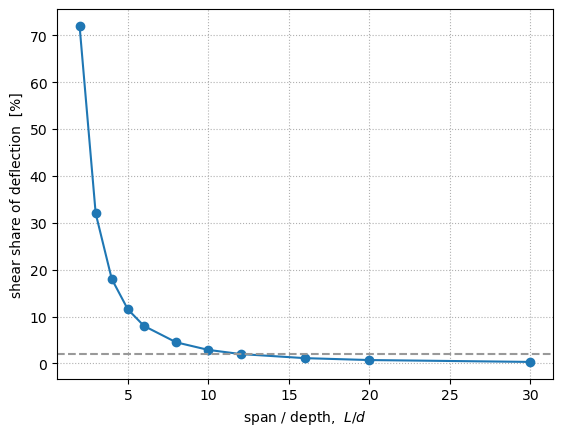

In [4]:
ratios = [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 30]
extra = []
for r in ratios:
    Lr = r * d
    eb = cba.BeamAnalysis([Lr], EI, [-1, 0, -1, 0])
    eb.add_pl(1, P, Lr / 2); eb.analyze()
    ti = cba.BeamAnalysis([Lr], EI, [-1, 0, -1, 0], GAv=GAv)
    ti.add_pl(1, P, Lr / 2); ti.analyze()
    de = eb.beam_results.results.D.min()
    dt = ti.beam_results.results.D.min()
    extra.append(100 * (dt - de) / de)

fig, ax = plt.subplots()
ax.plot(ratios, extra, "o-")
ax.axhline(2, ls="--", color="0.6")        # 2% guide
ax.set_xlabel("span / depth,  $L/d$")
ax.set_ylabel("shear share of deflection  [%]")
ax.grid(True, ls=":");

For deep or short members ($L/d \lesssim 8$) shear adds a large fraction of
the deflection; for slender members ($L/d \gtrsim 20$) it drops below a couple of
percent. That is why the Euler&ndash;Bernoulli default is appropriate for ordinary
girders, while the shear-deformable element is the right tool for deep beams,
transfer beams and short spans.

## Example 3 &mdash; Shear redistributes moments

Shear flexibility does not only add deflection &mdash; in an indeterminate
member it changes how moments are distributed. For a **propped cantilever**
(fixed&ndash;pinned) under a UDL the clamping moment is

$$M_\text{clamp} = \frac{wL^2}{2\,(4+\Phi)},$$

which reduces to the familiar Euler&ndash;Bernoulli $wL^2/8$ as $\Phi \to 0$ but
is *relaxed* by shear as $\Phi$ grows. We take a **deep** beam here
(span/depth&nbsp;3, $\Phi \approx 0.32$) so the effect is visible, and overlay the
two bending-moment diagrams with PyCBA's `plot_bmd` (which draws the BMD
sagging-positive, with the y-axis inverted in the usual structural convention).

clamp moment relaxes from -56.2 to -52.1 kN.m   (Phi = 0.32)


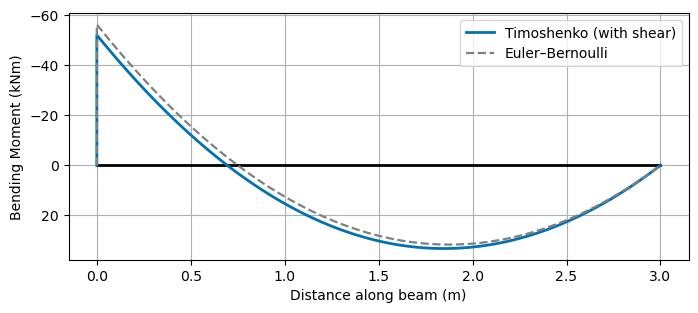

In [5]:
Ld = 3.0 * d          # a deep beam: span/depth = 3 (so shear's effect on M shows)
w = 50.0              # kN/m

eb3 = cba.BeamAnalysis([Ld], EI, [-1, -1, -1, 0])           # propped cantilever
eb3.add_udl(1, w); eb3.analyze()
ti3 = cba.BeamAnalysis([Ld], EI, [-1, -1, -1, 0], GAv=GAv)
ti3.add_udl(1, w); ti3.analyze()

me, mt = eb3.beam_results.results.M, ti3.beam_results.results.M
print(f"clamp moment relaxes from {me[np.abs(me).argmax()]:.1f} to "
      f"{mt[np.abs(mt).argmax()]:.1f} kN.m   (Phi = {12 * EI / (GAv * Ld**2):.2f})")

# overlay the two bending-moment diagrams on one axis
ax = ti3.plot_bmd(color="#0072B2", lw=2, label="Timoshenko (with shear)")
eb3.plot_bmd(ax=ax, color="0.5", ls="--", lw=1.6, label="Euler–Bernoulli")
ax.legend();

## Example 4 &mdash; Variable shear rigidity and non-prismatic members

`GAv` accepts a `SectionEI` to describe a shear rigidity $GA_v(x)$ that varies
along the member, exactly as `EI` does &mdash; and the two can be combined for a
member that is both non-prismatic *and* shear-deformable. Here a member tapers in
depth, so both $EI(x)$ and $GA_v(x)$ vary along the span; we overlay the deflected
shapes with and without shear using `plot_dsd`.

tip deflection:  E-B -5.26 mm  ->  Timoshenko -5.44 mm   (+3.5% from shear)


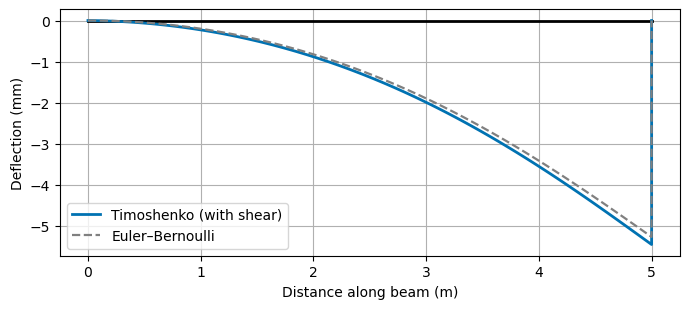

In [6]:
from pycba import SectionEI

# Linearly tapering depth d(x): 1.2 m at the support down to 0.6 m at the tip.
# EI ~ d^3 and GAv ~ d.
d0, d1 = 1.2, 0.6
GAv0, GAv1 = G * k * b * d0, G * k * b * d1

sec_EI = SectionEI([("poly", [0.0, L], lambda x: E * b * (d0 + (d1 - d0) * x / L)**3 / 12)])
sec_GAv = SectionEI([("linear", [0.0, L], [GAv0, GAv1])])

eb4 = cba.BeamAnalysis([L], sec_EI, [-1, -1, 0, 0])               # tapered cantilever
eb4.add_pl(1, P, L); eb4.analyze()
ti4 = cba.BeamAnalysis([L], sec_EI, [-1, -1, 0, 0], GAv=sec_GAv)  # + shear
ti4.add_pl(1, P, L); ti4.analyze()

te, tt = eb4.beam_results.results.D.min(), ti4.beam_results.results.D.min()
print(f"tip deflection:  E-B {te*1e3:.2f} mm  ->  Timoshenko {tt*1e3:.2f} mm"
      f"   (+{100 * (tt / te - 1):.1f}% from shear)")

# overlay the deflected shapes with PyCBA's plot_dsd
ax = ti4.plot_dsd(color="#0072B2", lw=2, label="Timoshenko (with shear)")
eb4.plot_dsd(ax=ax, color="0.5", ls="--", lw=1.6, label="Euler–Bernoulli")
ax.legend();

## Getting $GA_v$ for a real section

The shear rigidity is $GA_v = G\,A_v$ with $A_v = kA$. The shear coefficient $k$
depends on the cross-section shape:

| Section | shear coefficient $k$ |
|---|---|
| rectangle | $5/6 \approx 0.833$ |
| solid circle | $0.9$ |
| thin-walled tube | $0.5$ |
| I-section (strong axis) | $\approx A / A_\text{web}$ |

For an arbitrary section, the
[sectionproperties](https://sectionproperties.readthedocs.io) package computes
the shear areas directly from a warping analysis:

```python
# sketch (requires the `sectionproperties` package)
from sectionproperties.analysis import Section
sec.calculate_geometric_properties()
sec.calculate_warping_properties()
Av_x, Av_y = sec.get_as()        # shear areas about each axis
GAv = G * Av_y                   # transverse shear rigidity for bending
```

Pass the resulting `GAv` to `BeamAnalysis(..., GAv=GAv)` (or `add_span`) and the
member is analysed as a Timoshenko element.

## Summary

* Supply a finite **`GAv`** to make any member shear-deformable; leave it
  `None` for the exact Euler&ndash;Bernoulli element.
* Shear adds deflection ($\sim\Phi = 12EI/GA_vL^2$) and relaxes the moments of
  indeterminate members &mdash; significant for deep/short members, negligible
  for slender ones.
* `GAv` works for prismatic and non-prismatic members and all support/release
  types, and is inherited by the bridge and influence-line tools. The nonlinear
  (plastic-hinge) engine remains Euler&ndash;Bernoulli.